# Histogram Equalization

Welcome to the world of histogram equalization! Although we’ve already plotted histograms and even completed a project related to this technique in the previous module, in this module we will dive deeper into the fascinating realm of image processing and explore the concept of **histogram equalization**.

Histogram equalization is a powerful technique used in image processing to **redistribute the pixel intensity values of an image**, resulting in a more balanced and higher-contrast representation.

> By adjusting the distribution of pixel values, **we can enhance details and reveal hidden features**.

Throughout this notebook, we’ll explore the theory behind equalization, its applications across various domains, and how to implement it using OpenCV. We’ll cover equalization techniques for grayscale and color images, and also introduce a more advanced and specialized technique known as *Contrast Limited Adaptive Histogram Equalization* (CLAHE).

---

## Theory and Applications

Histogram equalization has a wide range of applications. It is commonly used in **image enhancement tasks**, where the goal is to improve the visual quality of images by enhancing contrast and revealing subtle details.

You'll find it used in many fields such as medical imaging, satellite imagery, surveillance systems, and more. Equalizing images that might be obscured due to poor lighting conditions can help reveal features that enable the extraction of previously ignored or hidden information.

A histogram represents the distribution of pixel intensities in an image—where the x-axis shows the intensity values and the y-axis shows the frequency of occurrence. Through equalization, we aim to spread the intensities across a broader range, achieving a more uniform distribution.

In essence, what we’re doing is remapping the original intensity values to new values using a transformation function that effectively "stretches" or "compresses" the values over the available range.

In the code snippet below, I use `numpy` just to give you an *intuition* about the theory. First, the histogram of the image is calculated using `np.histogram()`, which returns the histogram values (`hist`) and the bin edges (`bins`).

To compute the cumulative distribution function (CDF), we use `hist.cumsum()` and normalize it by scaling it to the histogram’s range. For normalization, we use:

```python
cdf_normalized = cdf * hist.max() / cdf.max()
```


/tmp/ipykernel_1881/339458790.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1].hist(image.flatten(), 256, [0, 256], color='r')


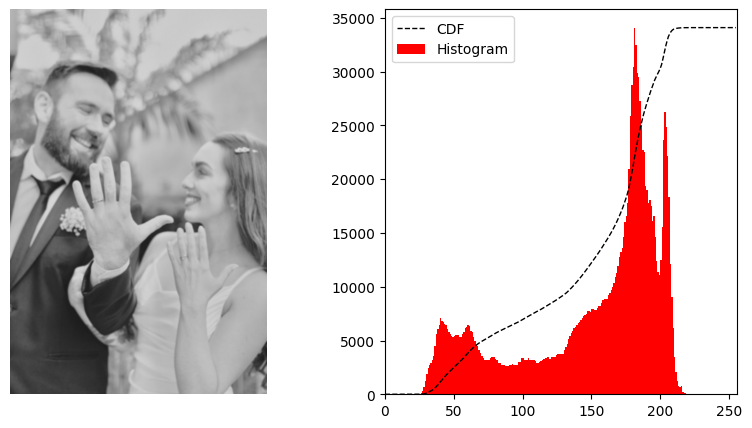

In [9]:
# Importing the necessary libraries
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

# Configuring display parameters for images and plots
matplotlib.rcParams['image.cmap'] = 'gray'
matplotlib.rcParams['image.interpolation'] = 'bicubic'
%matplotlib inline

# Load a photo in grayscale
image_path = Path.cwd().parent.parent / "data" / "mod02" / "image_hist.jpg"
image = cv2.imread(image_path, 0)

# Compute the histogram
hist, bins = np.histogram(image.flatten(), 256, [0, 256])

# Compute the cumulative distribution function (CDF)
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max() / cdf.max()

# Plot histogram and CDF
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image, vmin=0, vmax=255)
axs[0].axis('off')
axs[1].plot(cdf_normalized, color='black', linestyle='--', linewidth=1)
axs[1].set_xlim([0, 256])
axs[1].hist(image.flatten(), 256, [0, 256], color='r')
axs[1].legend(('CDF', 'Histogram'), loc='upper left')
plt.show()


In addition to understanding the theory, it's crucial to interpret the histogram and cumulative distribution function (CDF) in practice. The X-axis of the histogram represents pixel intensity values ranging from 0 (black) to 255 (white), while the Y-axis indicates the frequency of each intensity in the image. The CDF shows the cumulative sum of pixel frequencies up to each intensity level, providing insight into how pixel values are distributed across the image. It is always a monotonically increasing curve and is useful for remapping intensities during histogram equalization.

In the specific case of the image used here, the histogram shows a single, well-defined peak in the range of **150 to 200**, with intensity values mostly spanning from **25 to 225**. This indicates that the majority of pixel intensities are clustered in a moderately bright region, with very few pixels in the extremely dark or bright zones. The absence of values near 0 and 255 suggests that the image lacks both deep shadows and strong highlights, resulting in a low overall dynamic range.

The corresponding CDF reflects this behavior, appearing as a gradual, smooth curve with the steepest increase occurring between intensity levels 150 and 200—precisely where the peak lies. This pattern implies that most visual information is compressed within a narrow band of brightness, making the image appear flat or lacking contrast.

Histogram equalization in this context would serve to spread the pixel intensities more evenly across the available dynamic range (0–255), enhancing global contrast and revealing finer details, especially in areas that were previously too uniform in brightness.

To achieve this balanced distribution—and thereby improve contrast and visual quality—we can apply the concept of a masked array using NumPy.

Masked arrays are useful when handling cumulative distribution functions that include zero values, which would otherwise cause division-by-zero errors during normalization. By masking these zero values in the CDF, we ensure a stable and accurate transformation function. Here's how it works:



/tmp/ipykernel_1881/1940632274.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axs[1].hist(image2.flatten(), 256, [0, 256], color='r')


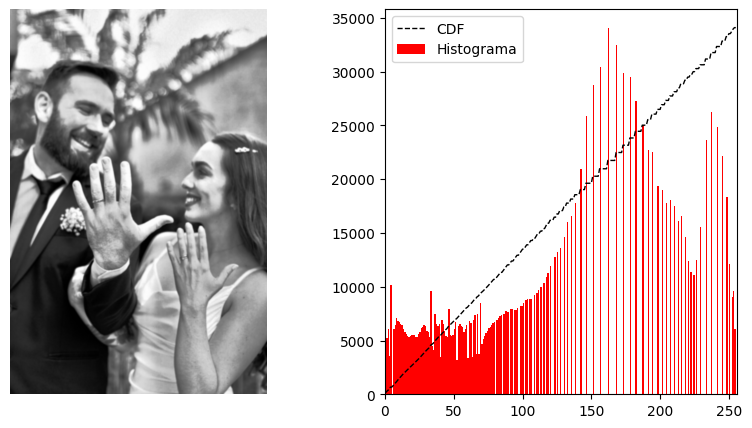

In [10]:
# Máscara para valores e normalização da CDF
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf = np.ma.filled(cdf_m, 0).astype('uint8')

# LUT (look-up table)
image2 = cdf[image]

# Novo histograma e CDF
hist2, bins2 = np.histogram(image2.flatten(), 256, [0, 256])
cdf2 = hist2.cumsum()
cdf_normalized2 = cdf2 * hist2.max() / cdf2.max()

# Plotar histograma e C.D.F.
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image2, vmin=0, vmax=255)
axs[0].axis('off')
axs[1].plot(cdf_normalized2, color='black', linestyle='--', linewidth=1)
axs[1].set_xlim([0, 256])
axs[1].hist(image2.flatten(), 256, [0, 256], color='r')
axs[1].legend(('CDF', 'Histograma'), loc='upper left')
plt.show()

## Histogram Equalization for Grayscale Images

The function [**cv.equalizeHist()**](https://docs.opencv.org/4.7.0/d6/dc7/group__imgproc__hist.html#ga7e54091f0c937d49bf84152a16f76d6e) performs histogram equalization on a grayscale image. Equalization involves mapping a distribution $H$ to another distribution $H'$ so that intensity values are spread across the entire range.

To apply histogram equalization, the remapping should be the cumulative distribution function (CDF). Follow this algorithm:

1. Compute the histogram $H$ of `src`.
2. Normalize the histogram so that the maximum value is 255 (or the maximum possible intensity value).
3. Compute the discrete integral of the histogram:

   $$
   H'_i = \sum_{0 \leq j < i} H(j)
   $$

4. Transform the image using $H'$ as a look-up table:

   $$
   \text{dst}(x, y) = H'(\text{src}(x, y))
   $$

This algorithm normalizes brightness and increases image contrast.

---

### <font style="color:rgb(8,133,37)">Function Syntax</font>


```python
retorn = cv.equalizeHist(src[, dst]) -> dst
```

**Parameters**

- **src** – Input image, 8-bit single-channel (grayscale).
- **dst** – Output image of the same size and type as the input image (`src`).

Histogram equalization is a technique used to adjust the contrast of an image by redistributing pixel values more evenly across the full intensity range. This can enhance the visual appearance of an image, making details more visible. The `cv.equalizeHist` function performs this process efficiently, making it a valuable tool in many image processing applications.


/tmp/ipykernel_1881/849463769.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.flatten(), 256, [0, 256])
/tmp/ipykernel_1881/849463769.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equalized.flatten(), 256, [0, 256])


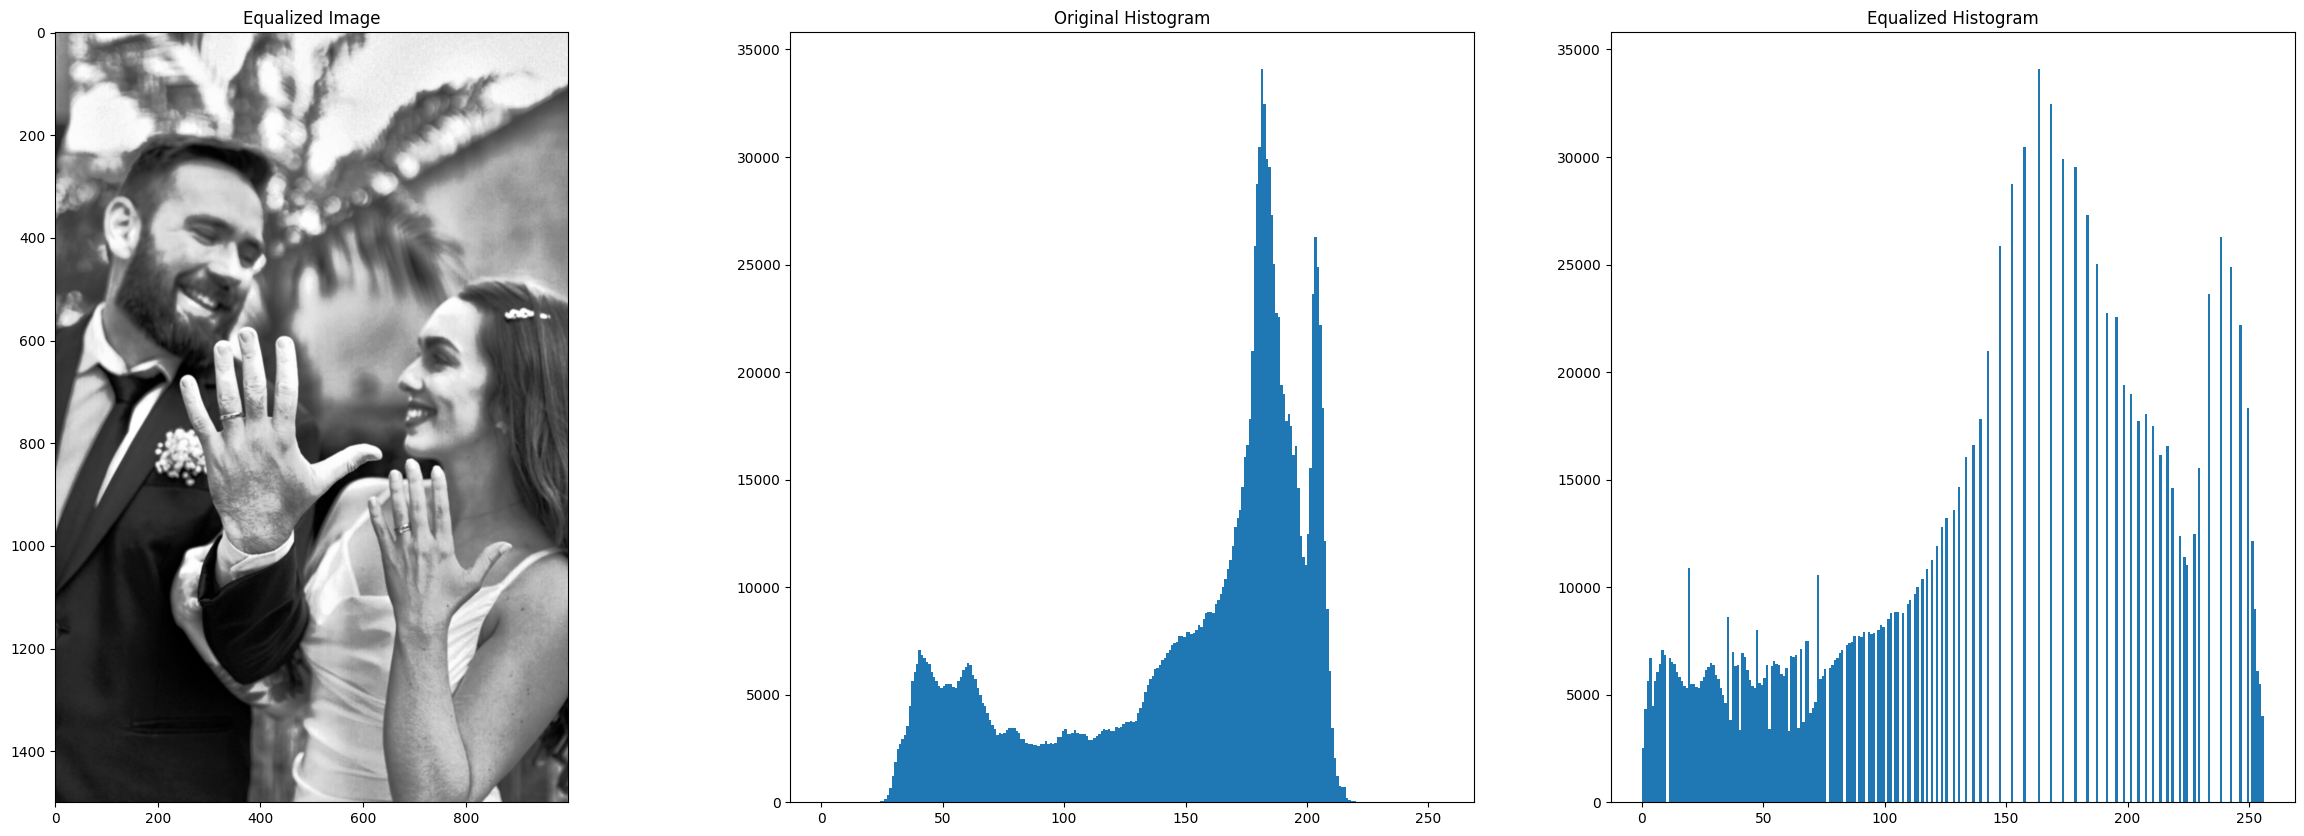

In [11]:
equalized = cv2.equalizeHist(image)

plt.figure(figsize=(30, 10))

# Display equalized image
plt.subplot(1, 3, 1)
plt.imshow(equalized, cmap='gray', vmin=0, vmax=255)
plt.title('Equalized Image')

# Compare histograms
# The original and equalized histograms are plotted side by side for analysis
plt.subplot(1, 3, 2)
plt.hist(image.flatten(), 256, [0, 256])
plt.title('Original Histogram')

plt.subplot(1, 3, 3)
plt.hist(equalized.flatten(), 256, [0, 256])
plt.title('Equalized Histogram')

plt.show()


### Histogram Equalization in Color Images

If we attempt to apply histogram equalization directly to color images by treating each of the three RGB channels separately, the result will often be poor and visually unexpected. This happens because each color channel undergoes a **nonlinear and independent transformation**, which can generate entirely new colors that are **not consistent with the original image**.

The correct approach to histogram equalization in color images involves a **preprocessing step**: converting the image to a **color space where intensity is separated**—such as **HSV**. This allows us to enhance contrast without distorting color information. The recommended steps are:

1. Convert the image from the RGB color space to **HSV**.
2. Apply histogram equalization **only on the V (value/brightness) channel**.
3. Convert the image **back to the RGB color space**.


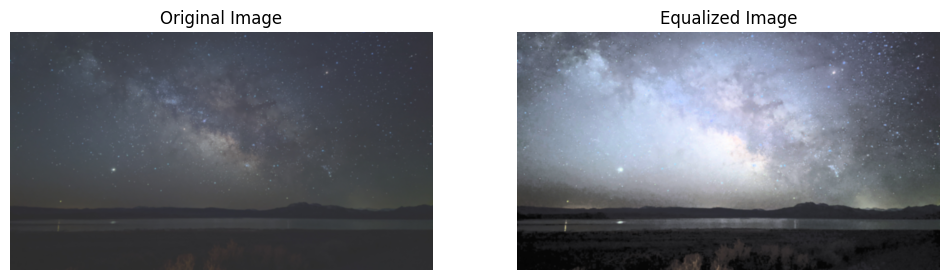

In [12]:
import cv2
import matplotlib.pyplot as plt

# Read the astrophotography image
image_path_astro = Path.cwd().parent.parent / "data" / "mod02" / "astrofoto.jpg"
astrofoto = cv2.imread(image_path_astro)

# Convert to HSV color space
hsv_astrofoto = cv2.cvtColor(astrofoto, cv2.COLOR_BGR2HSV)

# Split the HSV channels
h, s, v = cv2.split(hsv_astrofoto)

# Equalize the V (value) channel
v_equalized = cv2.equalizeHist(v)

# Merge the HSV channels back, with the equalized V channel
hsv_astrofoto = cv2.merge([h, s, v_equalized])

# Convert back to RGB color space
astrofoto_equalized = cv2.cvtColor(hsv_astrofoto, cv2.COLOR_HSV2RGB)

# Set up the figure
plt.figure(figsize=(12, 6))

# Show original image
plt.subplot(1, 2, 1)
plt.imshow(astrofoto[..., ::-1], vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')

# Show equalized image
plt.subplot(1, 2, 2)
plt.imshow(astrofoto_equalized, vmin=0, vmax=255)
plt.title('Equalized Image')
plt.axis('off')

plt.show()


## CLAHE (Contrast Limited Adaptive Histogram Equalization)

CLAHE, or Contrast Limited Adaptive Histogram Equalization, is an advanced image processing technique used to enhance contrast in an image. While standard histogram equalization applies the same transformation across the entire image (which can increase contrast but may also amplify noise and reduce dynamic range in areas that already have good contrast), CLAHE divides the image into small blocks, or "tiles" (usually 8x8), and applies histogram equalization to each of these blocks individually.

This allows contrast to be improved locally, preserving details and reducing noise. Additionally, the CLAHE method can limit the contrast amplification (hence the term "Contrast Limited"), preventing the noise amplification that can occur with regular histogram equalization.

The implementation of CLAHE in OpenCV is done using the `createCLAHE()` function. First, a CLAHE object is created with two optional arguments: `clipLimit` and `tileGridSize`.

`clipLimit` is the contrast limit, and `tileGridSize` is the size of the block for local equalization. Once the CLAHE object is created, the `apply()` method can be called on the input image to obtain the image with adaptive histogram equalization.

In summary, while histogram equalization is an effective technique for improving contrast in images, it can result in loss of detail and increased noise. CLAHE, on the other hand, provides adaptive and limited contrast enhancement, preserving image details and minimizing noise amplification.


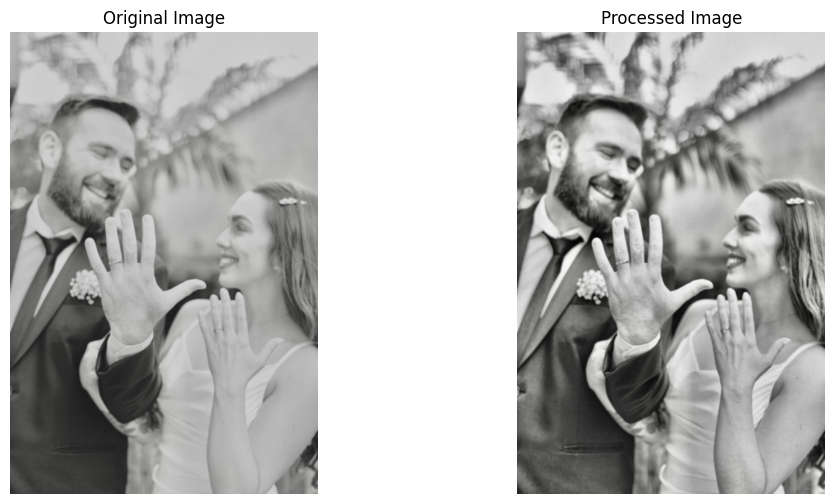

In [13]:
# Read the image
img = cv2.imread(image_path)

# Convert to HSV color space
img_hsv = img.copy()
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Create a CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_hsv[:, :, 2] = clahe.apply(img_hsv[:, :, 2])

# Convert back to RGB color space
img_equalized = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2BGR)
#cv2.imwrite('img_equalized.png', img_equalized)

# Set up the figure
plt.figure(figsize=(12, 6))

# Show original image
plt.subplot(1, 2, 1)
plt.imshow(img[..., ::-1], vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')

# Show processed image
plt.subplot(1, 2, 2)
plt.imshow(img_equalized[..., ::-1], vmin=0, vmax=255)
plt.title('Processed Image')
plt.axis('off')

plt.show()

